# When does white play Rb5?

How often, how soon, and at what stage of the game does white move a rook to b5 — across nearly a million master-level chess games?

## The dataset

**Lumbra's Gigabase OTB Elite** (June 2026 release):

- ~909,000 over-the-board games (no online play, no correspondence)
- Both players Elo ≥2400 — roughly FIDE Master and above
- Aggregated across TWIC weekly tournament PGNs, the (now-defunct) Caissabase historical corpus, national federation archives (BCF, Italian, Danish, Greek, Scottish, …), and live-broadcast capture from Lichess
- Date range 1848 to 2026; sparse pre-1900 (ratings retroactively assigned), dense post-2000

Each parquet shard preserves the full original PGN per game, so we can replay every position with `python-chess` and ask move-by-move questions like the ones below.

**Sample vs full corpus.** This notebook ships with a 100-game sample under `data/sample/games/`. To run against the full ~900k-game corpus, run `make data` once (~5 min for the download + index) and flip `USE_FULL_CORPUS = True` below. Position-level analysis of the full corpus takes ~90 seconds on a 14-core mac.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

from chess_corpus.analysis import map_shards, white_rook_to_b5

USE_FULL_CORPUS = False

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SHARD_DIR = ROOT / ("data/processed/games" if USE_FULL_CORPUS else "data/sample/games")
print(f"Reading shards from {SHARD_DIR}")

Reading shards from /Users/paul/pwsiegel/chess-move-stats/data/sample/games


/Users/paul/pwsiegel/chess-move-stats/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Replay every game and extract Rb5 stats

`white_rook_to_b5` walks each game's mainline once and records, per game, the first move number on which white moved a rook to b5, the material on the board at that moment, and the lowest material at any white-Rb5 in the game (in case there were several). Material is the standard P=1 N=B=3 R=5 Q=9 sum across both sides, kings excluded.

`map_shards` parallelizes across parquet shards (13 shards on the full corpus → one wave on 13 workers).

In [2]:
rb5 = pd.DataFrame(map_shards(white_rook_to_b5, shard_dir=SHARD_DIR))
print(f"Replayed {len(rb5):,} games.")
rb5.head()

shards:   0%|          | 0/1 [00:00<?, ?it/s]

shards: 100%|██████████| 1/1 [00:00<00:00,  3.23it/s]

shards: 100%|██████████| 1/1 [00:00<00:00,  3.23it/s]

Replayed 100 games.


,first_rb5_fullmove,first_material_at_rb5,min_material_at_rb5,n_white_moves
0,NaN,NaN,NaN,41
1,NaN,NaN,NaN,35
2,NaN,NaN,NaN,27
3,NaN,NaN,NaN,23
4,NaN,NaN,NaN,27


## How often does white play Rb5 at all?

First the unconditional rate: out of every master game in the corpus, what fraction sees white move a rook to b5 even once?

In [3]:
n_total = len(rb5)
n_with_rb5 = int(rb5["first_rb5_fullmove"].notna().sum())
pct = 100 * n_with_rb5 / n_total
print(f"Among all {n_total:,} games, {n_with_rb5:,} of them had white playing Rb5 — that comes out to {pct:.2f}%.")

Among all 100 games, 4 of them had white playing Rb5 — that comes out to 4.00%.


## When in the game does Rb5 happen? (CDF over move number)

Restrict to games where white plays Rb5, then ask: how soon does it happen? We record the **first** move number on which white moves a rook to b5, and build a cumulative distribution: P(first Rb5 ≤ move N | white plays Rb5).

**How to read the chart:** *"Among all games where white plays Rb5, the probability that it happens by move N is Y."* For example, the cell below pulls out the value at N=30 — that's how to phrase any point on the curve.

In [4]:
played = rb5[rb5["first_rb5_fullmove"].notna()].copy()
played["first_rb5_fullmove"] = played["first_rb5_fullmove"].astype(int)

max_n = 80
ns = np.arange(1, max_n + 1)
cdf_move = pd.DataFrame(
    {"N": ns, "prob": [(played["first_rb5_fullmove"] <= n).mean() for n in ns]}
)

example_n = 30
ex_p = cdf_move.loc[cdf_move["N"] == example_n, "prob"].iloc[0]
print(
    f"Example: among the {len(played):,} games where white plays Rb5, "
    f"the probability that it happens by move {example_n} is {ex_p:.1%}."
)

Example: among the 4 games where white plays Rb5, the probability that it happens by move 30 is 75.0%.


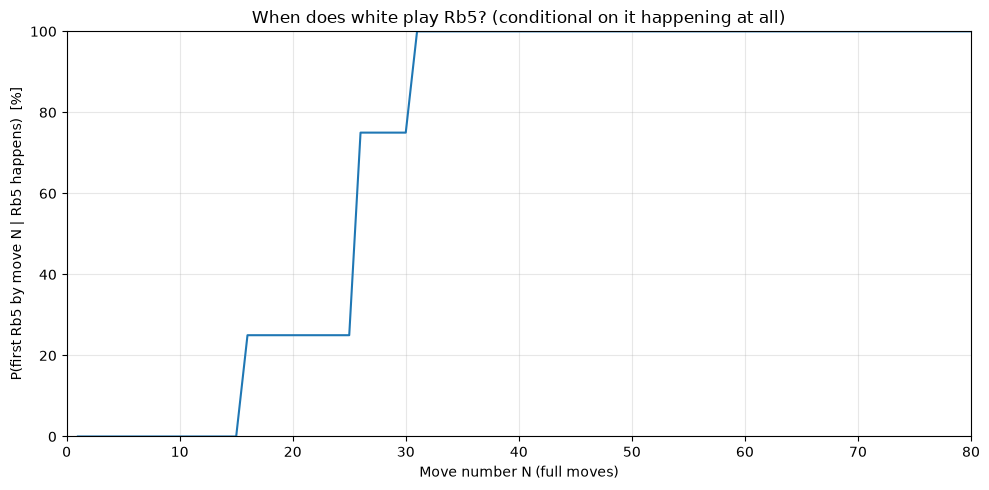

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cdf_move["N"], cdf_move["prob"] * 100)
ax.set_xlabel("Move number N (full moves)")
ax.set_ylabel("P(first Rb5 by move N | Rb5 happens)  [%]")
ax.set_title("When does white play Rb5? (conditional on it happening at all)")
ax.grid(alpha=0.3)
ax.set_xlim(0, max_n)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## At what material count does Rb5 happen? (CDF over material)

Still restricted to games where white plays Rb5. The starting position has 78 points of material total (39 per side: 8 pawns + 2 knights + 2 bishops + 2 rooks + 1 queen). We record the **lowest** material at any white Rb5 in each game — if material got down to, say, 30 by the time the rook reached b5, then the event "Rb5 with ≤30 material" happened.

**How to read the chart:** *"Among all games where white plays Rb5, the probability that the move happens with ≤M total points of material on the board is Y."* See the example sentence in the next cell.

In [6]:
min_mat = played["min_material_at_rb5"].astype(int)
ms = np.arange(0, 79)
cdf_mat = pd.DataFrame({"M": ms, "prob": [(min_mat <= m).mean() for m in ms]})

example_m = 40
ex_p = cdf_mat.loc[cdf_mat["M"] == example_m, "prob"].iloc[0]
print(
    f"Example: among the {len(played):,} games where white plays Rb5, "
    f"the probability that the move happens with ≤{example_m} points of material on the board is {ex_p:.1%}."
)

Example: among the 4 games where white plays Rb5, the probability that the move happens with ≤40 points of material on the board is 50.0%.


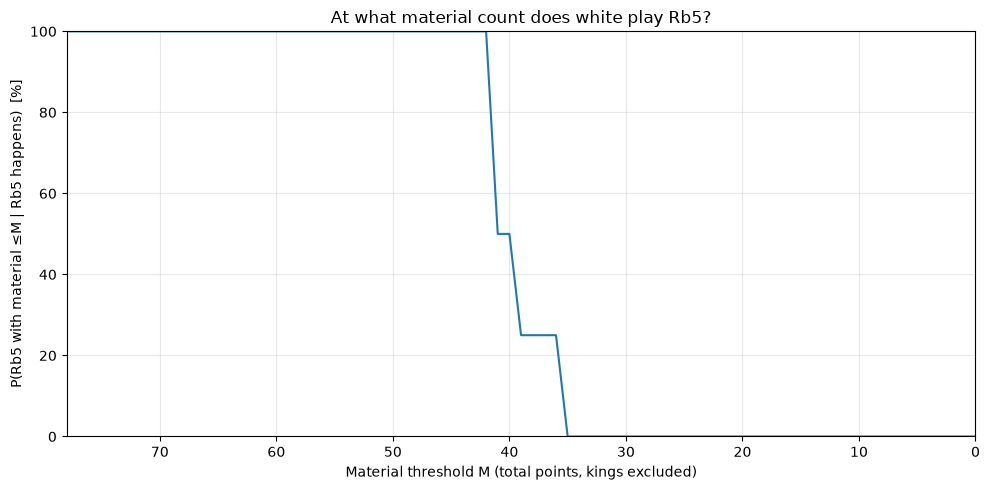

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cdf_mat["M"], cdf_mat["prob"] * 100)
ax.set_xlabel("Material threshold M (total points, kings excluded)")
ax.set_ylabel("P(Rb5 with material ≤M | Rb5 happens)  [%]")
ax.set_title("At what material count does white play Rb5?")
ax.set_xlim(0, 78)
ax.invert_xaxis()  # left = endgame, right = opening
ax.grid(alpha=0.3)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## Top 10 highest-rated whites to play Rb5 before the endgame

We define "before the endgame" as: the *first* Rb5 in the game happened with **more than 30 points of material** still on the board. 30 is a rough heuristic — both sides at roughly rook + minor + handful of pawns or richer, before pieces start trading down to king-and-pawn play.

Each entry below includes the PGN, which you can copy-paste into any analysis board (e.g. paste into Lichess: https://lichess.org/paste).

In [8]:
ENDGAME_MATERIAL_THRESHOLD = 30

# Align rb5 rows with the parquet's header columns. map_shards iterates
# sorted(glob) and preserves intra-shard order; pa.concat_tables over the
# same sorted shard list preserves the same order, so positional indices match.
shards = sorted(SHARD_DIR.glob("*.parquet"))
header_table = pa.concat_tables(
    [
        pq.read_table(
            s, columns=["white", "white_elo", "black", "black_elo", "event", "date", "result"]
        )
        for s in shards
    ]
)
headers_df = header_table.to_pandas().reset_index(drop=True)
combined = pd.concat([rb5.reset_index(drop=True), headers_df], axis=1)

qualifying = combined[
    combined["first_material_at_rb5"].notna()
    & (combined["first_material_at_rb5"] > ENDGAME_MATERIAL_THRESHOLD)
    & combined["white_elo"].notna()
]
print(
    f"{len(qualifying):,} games had white play Rb5 before the endgame "
    f"(material > {ENDGAME_MATERIAL_THRESHOLD} at first Rb5)."
)

top10 = qualifying.nlargest(10, "white_elo")[
    [
        "white",
        "white_elo",
        "black",
        "black_elo",
        "event",
        "date",
        "result",
        "first_rb5_fullmove",
        "first_material_at_rb5",
    ]
]
top10

4 games had white play Rb5 before the endgame (material > 30 at first Rb5).


,white,white_elo,black,black_elo,event,date,result,first_rb5_fullmove,first_material_at_rb5
93,"Grischuk, Alexander",2781,"Vachier-Lagrave, Maxime",2723,3. Norway Blitz 2015,2015.06.15,1/2-1/2,31.0,56.0
34,"Beikert, Guenther, Dr.",2438,"Marciano, David",2505,TCh-FRA Nat 1,2002.02.02,1/2-1/2,16.0,40.0
49,"Bellon Lopez, Juan Manuel",2415,"Gligorić, Svetozar",2530,Linares,1981.??.??,1-0,26.0,42.0
50,"Bellon Lopez, Juan Manuel",2415,"Gligoric, Sofija",2530,Linares,1981.01.01,1-0,26.0,42.0


### Their PGNs

Copy any block below into a Lichess/ChessBase analysis board to replay.

In [9]:
pgn_table = pa.concat_tables([pq.read_table(s, columns=["pgn"]) for s in shards])
pgns = pgn_table.to_pandas().reset_index(drop=True)["pgn"]

for i, (idx, row) in enumerate(top10.iterrows(), start=1):
    header = (
        f"# {i}. {row['white']} ({int(row['white_elo'])}) vs "
        f"{row['black']} ({int(row['black_elo']) if pd.notna(row['black_elo']) else '?'})  "
        f"— {row['event']}, {row['date']}, result {row['result']}"
    )
    print(header)
    print(
        f"# first Rb5: move {int(row['first_rb5_fullmove'])} with "
        f"{int(row['first_material_at_rb5'])} points of material on the board\n"
    )
    print(pgns.iloc[idx])
    print("\n" + "=" * 80 + "\n")

# 1. Grischuk, Alexander (2781) vs Vachier-Lagrave, Maxime (2723)  — 3. Norway Blitz 2015, 2015.06.15, result 1/2-1/2
# first Rb5: move 31 with 56 points of material on the board

[Event "3. Norway Blitz 2015"]
[Site "Stavanger NOR"]
[Date "2015.06.15"]
[Round "6.3"]
[White "Grischuk, Alexander"]
[Black "Vachier-Lagrave, Maxime"]
[Result "1/2-1/2"]
[PlyCount "101"]
[WhiteElo "2781"]
[WhiteFideId "4126025"]
[WhiteTitle "GM"]
[BlackElo "2723"]
[BlackFideId "623539"]
[BlackTitle "GM"]
[ECO "B23m"]
[Source "PGNMentor"]
[SourceQuality "1"]
[ImportDate "2026-01-06"]

1. Nc3 c5 2. e4 Nc6 3. Bb5 Nd4 4. Nf3 a6 5. Bd3 Nc6 6. e5 e6 7. O-O d5 8. exd6 Bxd6 9. Ne4 Be7 10. b3 f5 11. Ng3 Bf6 12. Rb1 g6 13. Re1 Nge7 14. Bb2 Bxb2 15. Rxb2 O-O 16. a4 Nd5 17. Bc4 Qf6 18. Rb1 Bd7 19. c3 Rad8 20. b4 cxb4 21. Bxd5 exd5 22. cxb4 f4 23. Nf1 Bg4 24. h3 Bxf3 25. Qxf3 Nd4 26. Qd3 f3 27. g3 Ne2+ 28. Kh2 d4 29. b5 a5 30. b6 Kh8 31. Rb5 Rc8 32. Rxa5 Qxb6 33. Rb5 Qa6 34. Qb3 Rc7 35. Rb1 Rff7 36. a5 Qf6 37. Qd5 Rcd7 3